# Flower Classification with Transfer Learning

This notebook trains a 5-class flower classifier with **MobileNetV2** using two transfer-learning strategies:

1. **Feature extraction** with a frozen pretrained backbone.
2. **Fine tuning** the top MobileNetV2 layers with a smaller learning rate.

The workflow loads the dataset from the folder structure, evaluates both approaches on a validation split, visualizes predictions, and exports a CSV submission for the unlabeled test set.


In [1]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
VAL_SPLIT = 0.20
SEED = 42
FEATURE_EPOCHS = 8
FINE_TUNE_EPOCHS = 6
AUTOTUNE = tf.data.AUTOTUNE
MOBILENET_INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3)

candidate_data_dirs = [
    Path(r"F:\ML\CV_Project2_Codebase\5-flowers-image-classification"),
    Path("5-flowers-image-classification"),
]
DATA_DIR = next((path for path in candidate_data_dirs if path.exists()), None)

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not locate the flower dataset. Update candidate_data_dirs if the dataset lives somewhere else."
    )

TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"
FEATURE_MODEL_PATH = DATA_DIR / "mobilenetv2_feature_extractor_best.keras"
FINE_TUNED_MODEL_PATH = DATA_DIR / "mobilenetv2_fine_tuned_best.keras"
FINAL_MODEL_PATH = DATA_DIR / "mobilenetv2_final_flower_classifier.keras"
SUBMISSION_PATH = DATA_DIR / "submission_mobilenetv2_transfer_learning.csv"

if not TRAIN_DIR.exists() or not TEST_DIR.exists():
    raise FileNotFoundError("Expected both train and test folders inside the dataset directory.")

def list_image_files(folder):
    return sorted(
        [
            path
            for path in folder.iterdir()
            if path.is_file() and path.suffix.lower() in {".jpg", ".jpeg", ".png"}
        ]
    )

print("TensorFlow version:", tf.__version__)
print("Dataset directory:", DATA_DIR.resolve())


TensorFlow version: 2.21.0
Dataset directory: F:\ML\CV_Project2_Codebase\5-flowers-image-classification


In [2]:
class_names = sorted([folder.name for folder in TRAIN_DIR.iterdir() if folder.is_dir()])
num_classes = len(class_names)
class_to_label = {name: idx for idx, name in enumerate(class_names)}
train_counts = {name: len(list_image_files(TRAIN_DIR / name)) for name in class_names}
test_paths = sorted(
    list_image_files(TEST_DIR),
    key=lambda path: int(path.stem) if path.stem.isdigit() else path.stem,
)
test_ids = [path.stem for path in test_paths]

print("Images per class:")
for name in class_names:
    print(f"  {name:<10} -> {train_counts[name]}")

print("\nLabel mapping:")
for name, idx in class_to_label.items():
    print(f"  {idx}: {name}")

print(f"\nNumber of classes: {num_classes}")
print(f"Total training images: {sum(train_counts.values())}")
print(f"Test images: {len(test_paths)}")

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    class_names=class_names,
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
)

train_ds = train_ds.shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

sample_images, sample_labels = next(iter(train_ds.take(1)))
print("\nSample batch shapes:")
print("  images:", sample_images.shape)
print("  labels:", sample_labels.shape)


Images per class:
  daisy      -> 691
  dandelion  -> 951
  rose       -> 694
  sunflower  -> 659
  tulip      -> 870

Label mapping:
  0: daisy
  1: dandelion
  2: rose
  3: sunflower
  4: tulip

Number of classes: 5
Total training images: 3865
Test images: 400
Found 3865 files belonging to 5 classes.
Using 3092 files for training.
Found 3865 files belonging to 5 classes.
Using 773 files for validation.

Sample batch shapes:
  images: (32, 224, 224, 3)
  labels: (32,)


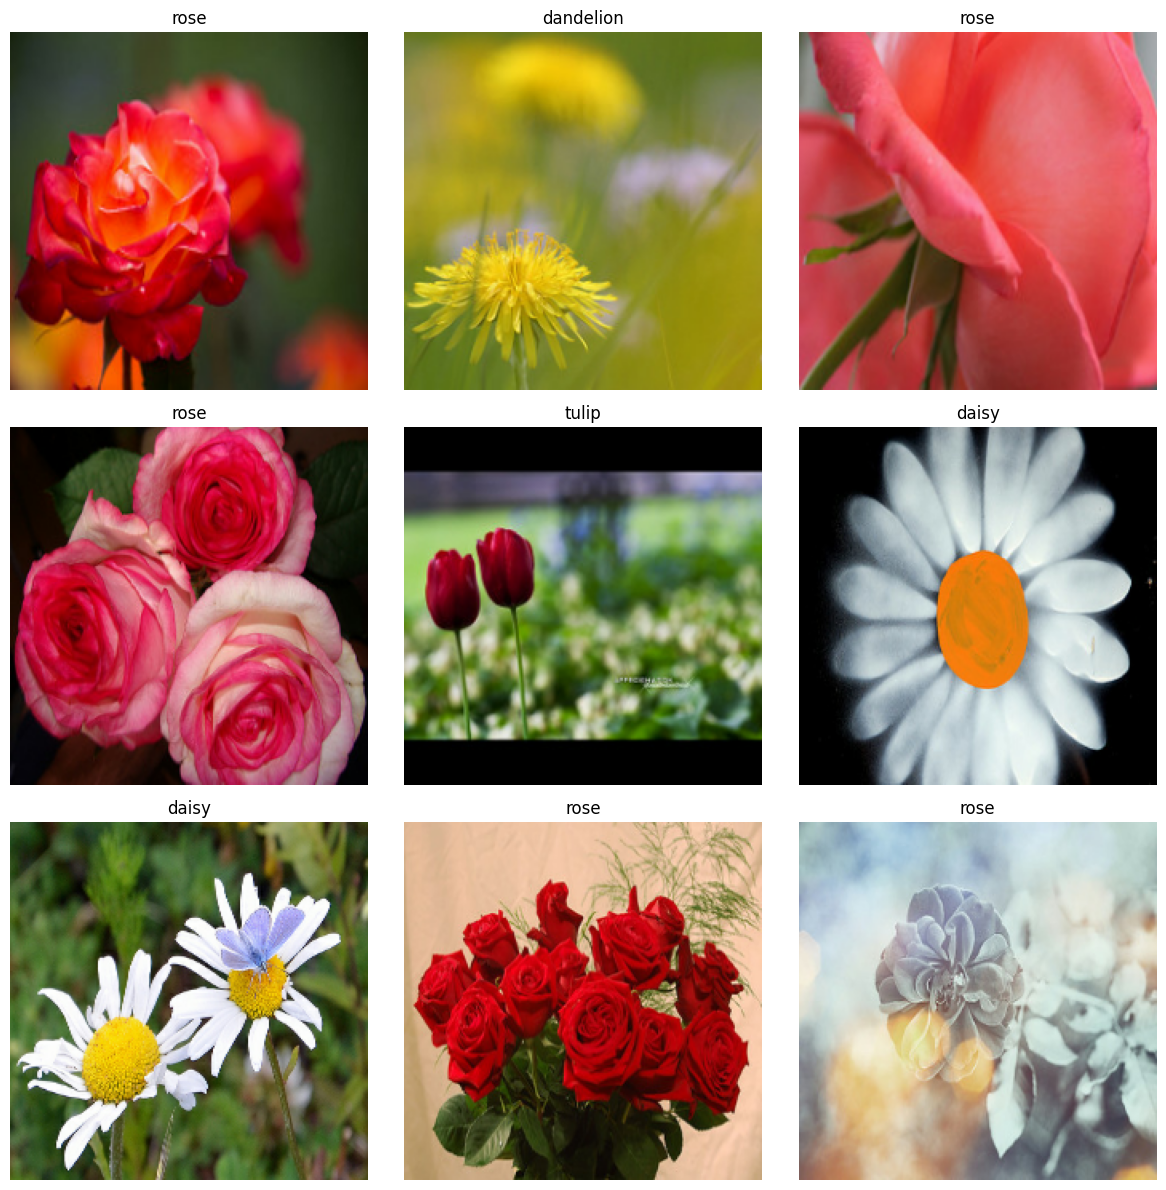

In [3]:
plt.figure(figsize=(12, 12))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(sample_images[i].numpy().astype("uint8"))
    plt.title(class_names[int(sample_labels[i].numpy())])
    plt.axis("off")
plt.tight_layout()


In [4]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.15),
    ],
    name="data_augmentation",
)

def build_transfer_model(dropout_rate=0.25):
    try:
        base_model = tf.keras.applications.MobileNetV2(
            input_shape=MOBILENET_INPUT_SHAPE,
            include_top=False,
            weights="imagenet",
        )
    except Exception as exc:
        raise RuntimeError(
            "MobileNetV2 ImageNet weights could not be loaded. Ensure internet access or cached weights are available."
        ) from exc

    base_model.trainable = False

    inputs = keras.Input(shape=MOBILENET_INPUT_SHAPE)
    x = data_augmentation(inputs)
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = keras.Model(inputs, outputs, name="mobilenetv2_transfer_learning")
    return model, base_model

def get_callbacks(model_path):
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.2,
            patience=2,
            min_lr=1e-7,
            verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=model_path,
            monitor="val_accuracy",
            save_best_only=True,
        ),
    ]

def plot_history(histories, fine_tune_start=None):
    merged_history = {}
    for partial_history in histories:
        for key, values in partial_history.history.items():
            merged_history.setdefault(key, []).extend(values)

    epochs = range(1, len(merged_history["loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs, merged_history["loss"], marker="o", label="train")
    axes[0].plot(epochs, merged_history["val_loss"], marker="o", label="validation")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(epochs, merged_history["accuracy"], marker="o", label="train")
    axes[1].plot(epochs, merged_history["val_accuracy"], marker="o", label="validation")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    if fine_tune_start is not None:
        for ax in axes:
            ax.axvline(fine_tune_start + 0.5, color="black", linestyle="--", alpha=0.7)

    plt.tight_layout()
    return merged_history

def evaluate_model(model, dataset, title):
    loss, accuracy = model.evaluate(dataset, verbose=0)
    print(f"{title} loss: {loss:.4f}")
    print(f"{title} accuracy: {accuracy:.4f}")

    y_true = np.concatenate([labels.numpy() for _, labels in dataset], axis=0)
    y_prob = model.predict(dataset, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    confusion = tf.math.confusion_matrix(y_true, y_pred, num_classes=num_classes).numpy()

    plt.figure(figsize=(8, 6))
    plt.imshow(confusion, interpolation="nearest", cmap="Blues")
    plt.title(f"{title} Confusion Matrix")
    plt.colorbar()

    tick_marks = np.arange(num_classes)
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)

    threshold = confusion.max() / 2 if confusion.max() else 0
    for i in range(confusion.shape[0]):
        for j in range(confusion.shape[1]):
            plt.text(
                j,
                i,
                str(confusion[i, j]),
                ha="center",
                va="center",
                color="white" if confusion[i, j] > threshold else "black",
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

    per_class_accuracy = confusion.diagonal() / np.maximum(confusion.sum(axis=1), 1)
    print("\nPer-class accuracy:")
    for name, class_accuracy in zip(class_names, per_class_accuracy):
        print(f"  {name:<10} -> {class_accuracy:.3f}")

    return {"loss": loss, "accuracy": accuracy}

def preview_validation_predictions(model, dataset, rows=2, cols=4):
    images, labels = next(iter(dataset.take(1)))
    probabilities = model.predict(images, verbose=0)
    predictions = np.argmax(probabilities, axis=1)
    confidences = np.max(probabilities, axis=1)

    num_images = min(rows * cols, len(predictions))
    plt.figure(figsize=(4 * cols, 4 * rows))

    for i in range(num_images):
        ax = plt.subplot(rows, cols, i + 1)
        display_image = np.clip(images[i].numpy(), 0, 255).astype("uint8")
        true_idx = int(labels[i].numpy())
        pred_idx = int(predictions[i])
        is_correct = true_idx == pred_idx

        plt.imshow(display_image)
        plt.title(
            f"true: {class_names[true_idx]}\npred: {class_names[pred_idx]} ({confidences[i]:.2f})",
            color="green" if is_correct else "red",
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

def build_test_dataset(paths):
    def load_image(path):
        image_bytes = tf.io.read_file(path)
        image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
        image.set_shape([None, None, 3])
        image = tf.image.resize(tf.cast(image, tf.float32), (IMG_HEIGHT, IMG_WIDTH))
        return image

    test_ds = tf.data.Dataset.from_tensor_slices([str(path) for path in paths])
    return test_ds.map(load_image, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

def preview_test_predictions(model, dataset, ids, rows=2, cols=4):
    images = next(iter(dataset.take(1)))
    probabilities = model.predict(images, verbose=0)
    predictions = np.argmax(probabilities, axis=1)
    confidences = np.max(probabilities, axis=1)

    num_images = min(rows * cols, len(predictions))
    plt.figure(figsize=(4 * cols, 4 * rows))

    for i in range(num_images):
        ax = plt.subplot(rows, cols, i + 1)
        plt.imshow(np.clip(images[i].numpy(), 0, 255).astype("uint8"))
        plt.title(f"id={ids[i]}\n{class_names[int(predictions[i])]} ({confidences[i]:.2f})")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


In [5]:
feature_extractor_model, base_model = build_transfer_model(dropout_rate=0.25)
feature_extractor_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

feature_extractor_model.summary()

feature_history = feature_extractor_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FEATURE_EPOCHS,
    callbacks=get_callbacks(FEATURE_MODEL_PATH),
)

best_feature_model = keras.models.load_model(FEATURE_MODEL_PATH)


Model: "mobilenetv2_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/8
97/97 ━━━━━━━━━━━━━━━━━━━━ 34s 295ms/step - accuracy: 0.6630 - loss: 0.8759 - val_accuracy: 0.8241 - val_loss: 0.5253 - learning_rate: 0.0010
Epoch 2/8
97/97 ━━━━━━━━━━━━━━━━━━━━ 27s 274ms/step - accuracy: 0.8364 - loss: 0.4832 - val_accuracy: 0.8370 - val_loss: 0.4510 - learning_rate: 0.0010
Epoch 3/8
97/97 ━━━━━━━━━━━━━━━━━━━━ 28s 281ms/step - accuracy: 0.8583 - loss: 0.3994 - val_accuracy: 0.8590 - val_loss: 0.4256 - learning_rate: 0.0010
Epoch 4/8
97/97 ━━━━━━━━━━━━━━━━━━━━ 28s 285ms/step - accuracy: 0.8680 - loss: 0.3623 - val_accuracy: 0.8603 - val_loss: 0.4009 - learning_rate: 0.0010
Epoch 5/8
97/97 ━━━━━━━━━━━━━━━━━━━━ 27s 268ms/step - accuracy: 0.8742 - loss: 0.3488 - val_accuracy: 0.8655 - val_loss: 0.3898 - learning_rate: 0.0010
Epoch 6/8
97/97 ━━━━━━━━━━━━━━━━━━━━ 27s 273ms/step - accuracy: 0.8952 - loss: 0.3004 - val_accuracy: 0.8577 - val_loss: 0.3960 - learning_rate: 0.0010
Epoch 7/8
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.9036 - loss: 0.2798
Epo

Feature Extractor loss: 0.3775
Feature Extractor accuracy: 0.8693


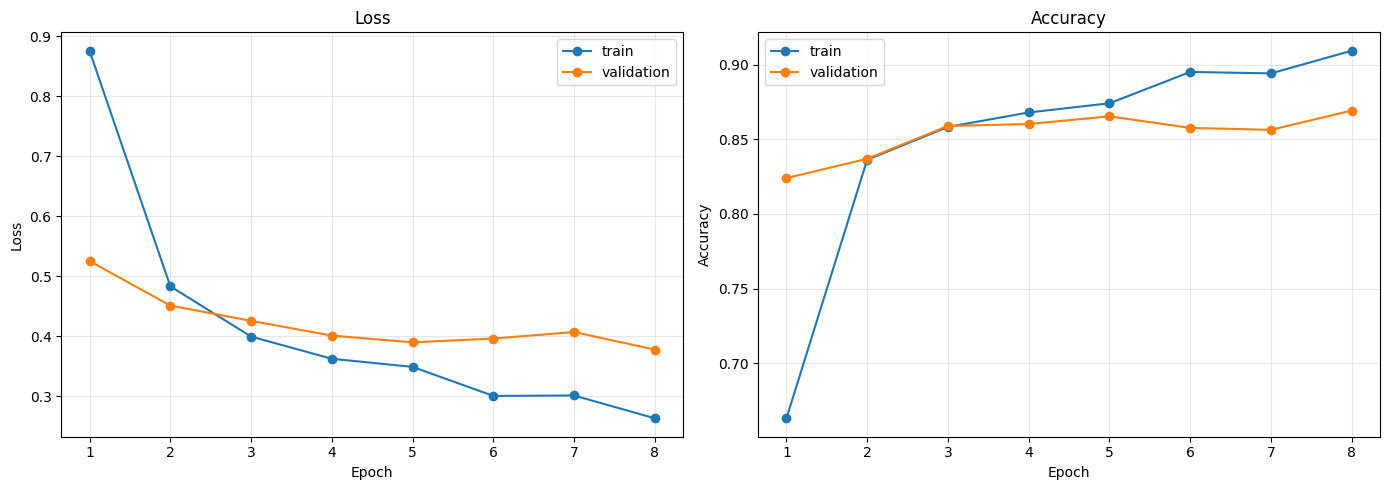

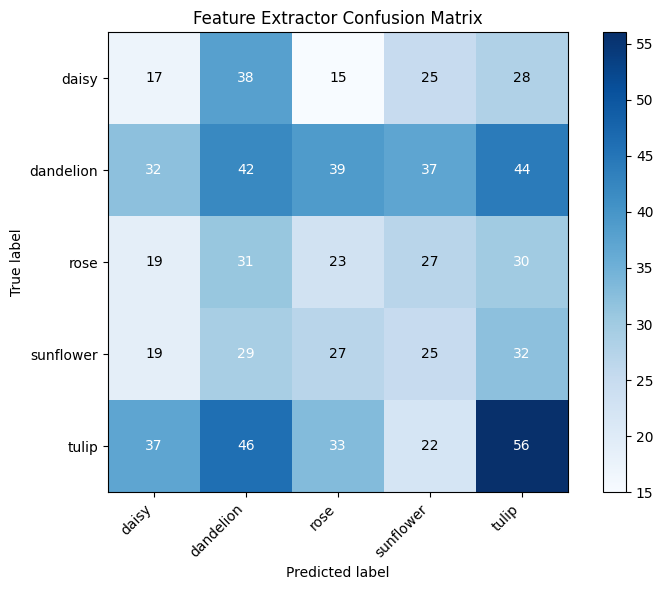


Per-class accuracy:
  daisy      -> 0.138
  dandelion  -> 0.216
  rose       -> 0.177
  sunflower  -> 0.189
  tulip      -> 0.289


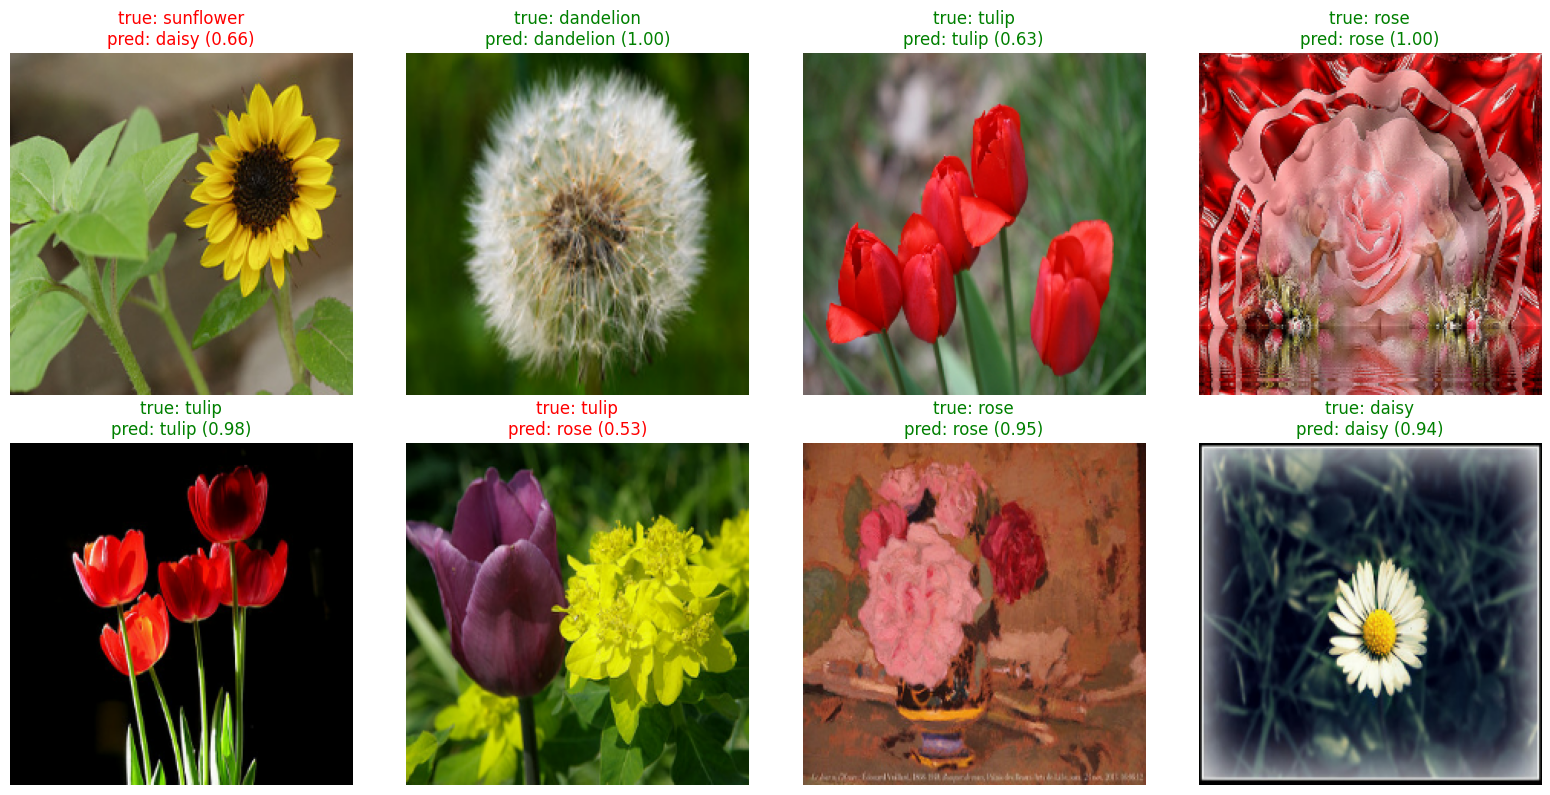

In [6]:
plot_history([feature_history])
feature_metrics = evaluate_model(best_feature_model, val_ds, "Feature Extractor")
preview_validation_predictions(best_feature_model, val_ds)


## Step 2: Fine Tuning

Next, we unfreeze the top part of MobileNetV2 and continue training with a much smaller learning rate. This lets the pretrained features adapt more specifically to the flower dataset.


In [7]:
fine_tune_layers = 40
base_model.trainable = True

for layer in base_model.layers[:-fine_tune_layers]:
    layer.trainable = False

for layer in base_model.layers[-fine_tune_layers:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print(f"Fine-tuning the last {fine_tune_layers} MobileNetV2 layers.")
print(
    f"Trainable layers inside MobileNetV2: "
    f"{sum(layer.trainable for layer in base_model.layers)} / {len(base_model.layers)}"
)

feature_epochs_ran = len(feature_history.history["loss"])
total_epochs = feature_epochs_ran + FINE_TUNE_EPOCHS

feature_extractor_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

fine_tune_history = feature_extractor_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=feature_epochs_ran,
    callbacks=get_callbacks(FINE_TUNED_MODEL_PATH),
)

best_fine_tuned_model = keras.models.load_model(FINE_TUNED_MODEL_PATH)


Fine-tuning the last 40 MobileNetV2 layers.
Trainable layers inside MobileNetV2: 26 / 154
Epoch 9/14
97/97 ━━━━━━━━━━━━━━━━━━━━ 40s 328ms/step - accuracy: 0.8946 - loss: 0.2813 - val_accuracy: 0.8719 - val_loss: 0.3779 - learning_rate: 1.0000e-05
Epoch 10/14
97/97 ━━━━━━━━━━━━━━━━━━━━ 33s 333ms/step - accuracy: 0.9169 - loss: 0.2303 - val_accuracy: 0.8926 - val_loss: 0.3427 - learning_rate: 1.0000e-05
Epoch 11/14
97/97 ━━━━━━━━━━━━━━━━━━━━ 33s 328ms/step - accuracy: 0.9292 - loss: 0.2007 - val_accuracy: 0.8978 - val_loss: 0.3327 - learning_rate: 1.0000e-05
Epoch 12/14
97/97 ━━━━━━━━━━━━━━━━━━━━ 32s 327ms/step - accuracy: 0.9276 - loss: 0.1874 - val_accuracy: 0.8926 - val_loss: 0.3292 - learning_rate: 1.0000e-05
Epoch 13/14
97/97 ━━━━━━━━━━━━━━━━━━━━ 31s 312ms/step - accuracy: 0.9450 - loss: 0.1541 - val_accuracy: 0.8900 - val_loss: 0.3353 - learning_rate: 1.0000e-05
Epoch 14/14
97/97 ━━━━━━━━━━━━━━━━━━━━ 31s 315ms/step - accuracy: 0.9405 - loss: 0.1649 - val_accuracy: 0.8978 - val_loss

Fine-Tuned Model loss: 0.3327
Fine-Tuned Model accuracy: 0.8978


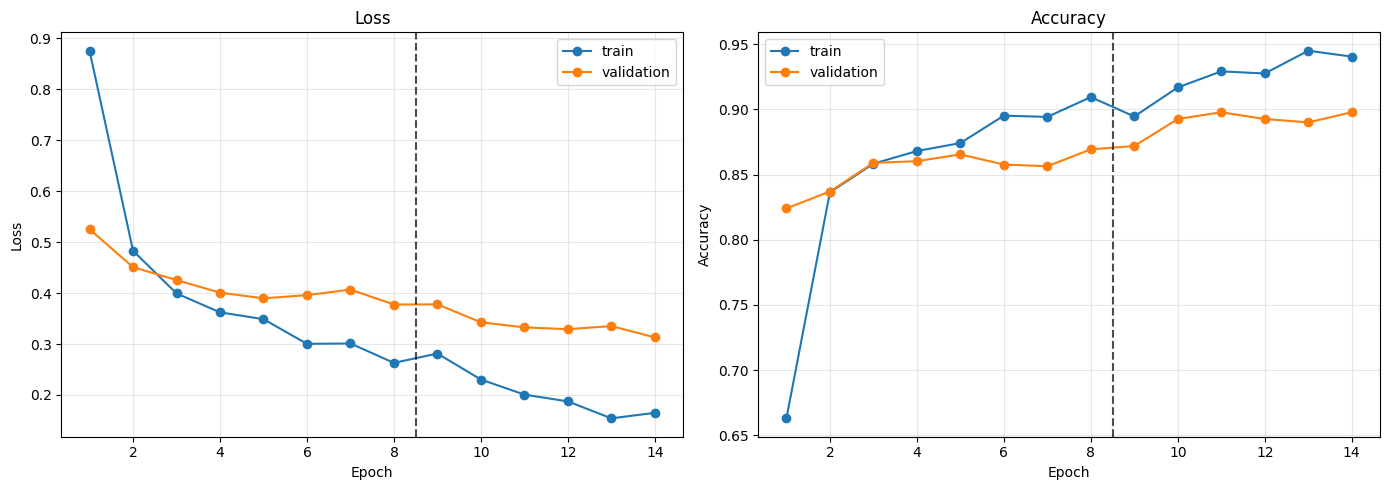

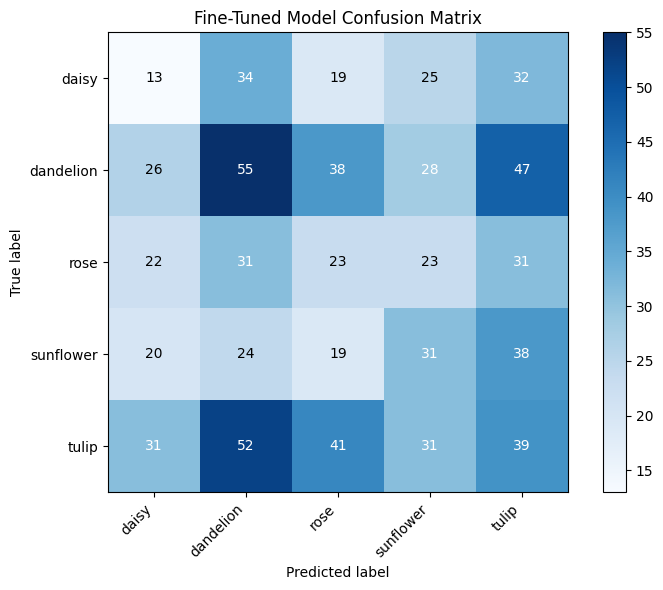


Per-class accuracy:
  daisy      -> 0.106
  dandelion  -> 0.284
  rose       -> 0.177
  sunflower  -> 0.235
  tulip      -> 0.201

Validation comparison:
  Feature extractor accuracy: 0.8693
  Fine-tuned model accuracy:  0.8978
  Accuracy gain:             +0.0285

Selected final model: Fine-tuned MobileNetV2


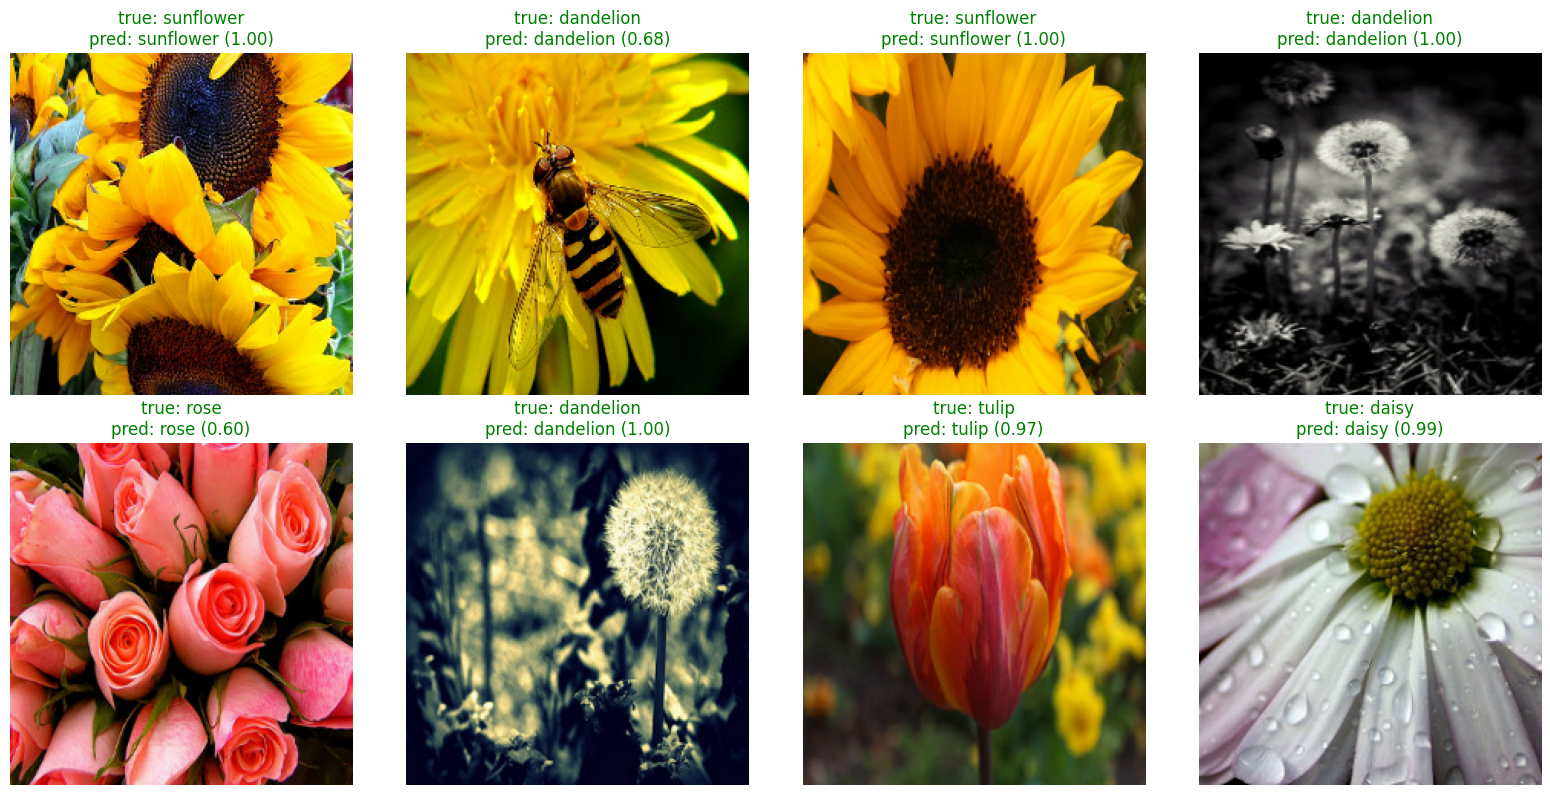

In [8]:
plot_history([feature_history, fine_tune_history], fine_tune_start=feature_epochs_ran)
fine_tuned_metrics = evaluate_model(best_fine_tuned_model, val_ds, "Fine-Tuned Model")

print("\nValidation comparison:")
print(f"  Feature extractor accuracy: {feature_metrics['accuracy']:.4f}")
print(f"  Fine-tuned model accuracy:  {fine_tuned_metrics['accuracy']:.4f}")
print(
    f"  Accuracy gain:             "
    f"{fine_tuned_metrics['accuracy'] - feature_metrics['accuracy']:+.4f}"
)

if fine_tuned_metrics["accuracy"] >= feature_metrics["accuracy"]:
    best_model = best_fine_tuned_model
    best_model_name = "Fine-tuned MobileNetV2"
else:
    best_model = best_feature_model
    best_model_name = "Frozen MobileNetV2 feature extractor"

print(f"\nSelected final model: {best_model_name}")
preview_validation_predictions(best_model, val_ds)


## Predict on the Test Set

The final step uses the better validation model to predict labels for the unlabeled test images and saves a Kaggle-style submission file with `id,label` columns.


Preview of test predictions:
  id=1 -> sunflower (1.00)
  id=2 -> tulip (0.82)
  id=3 -> tulip (0.68)
  id=4 -> dandelion (0.94)
  id=5 -> dandelion (1.00)
  id=6 -> tulip (0.97)
  id=7 -> tulip (0.98)
  id=8 -> daisy (1.00)
  id=9 -> dandelion (1.00)
  id=10 -> daisy (0.63)

Saved submission to: F:\ML\CV_Project2_Codebase\5-flowers-image-classification\submission_mobilenetv2_transfer_learning.csv


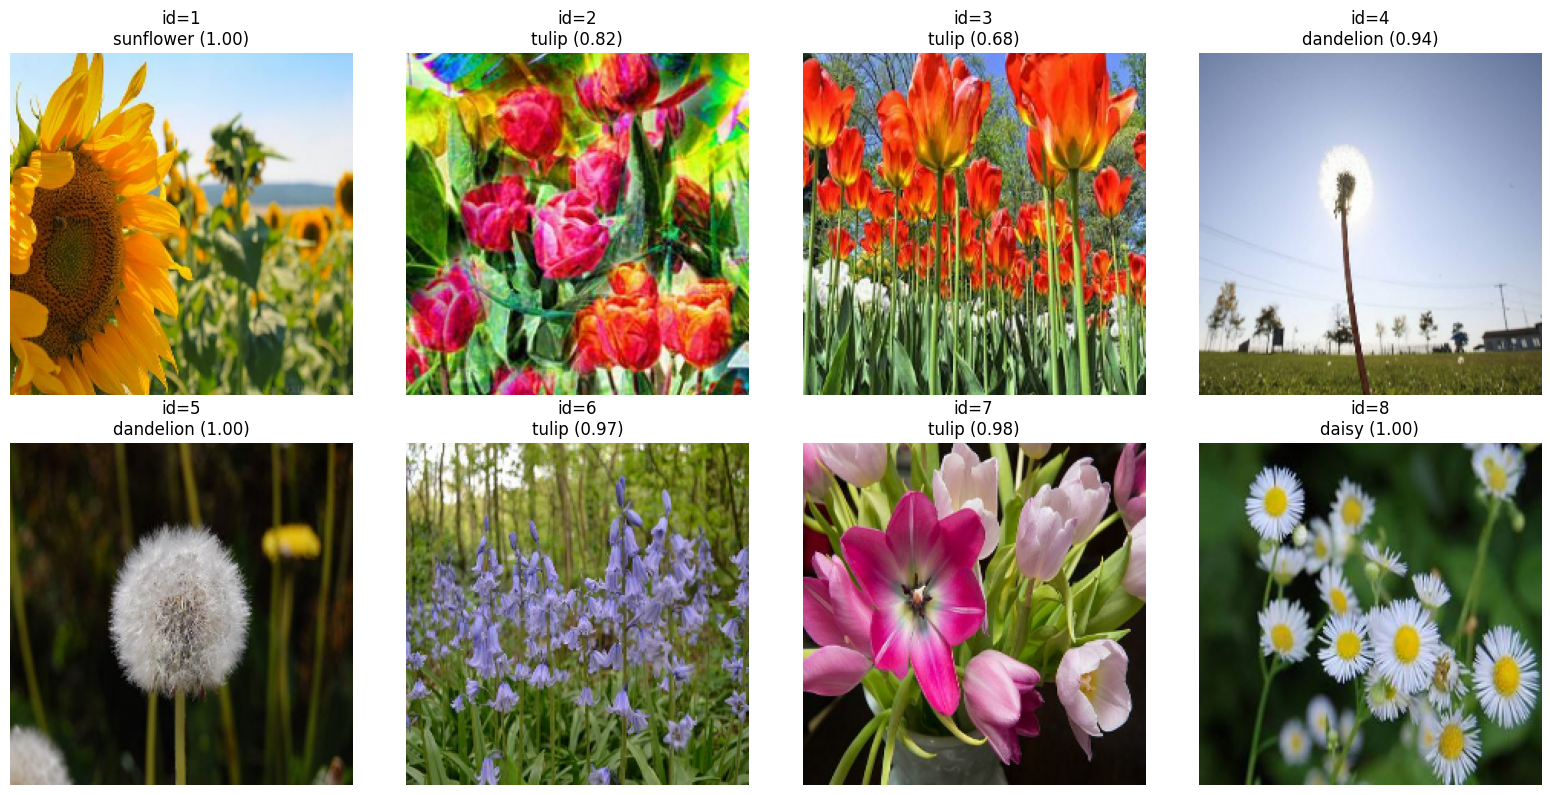

In [9]:
test_ds = build_test_dataset(test_paths)
test_probabilities = best_model.predict(test_ds, verbose=0)
test_predictions = np.argmax(test_probabilities, axis=1)
test_confidences = np.max(test_probabilities, axis=1)

with SUBMISSION_PATH.open("w", newline="", encoding="utf-8") as csv_file:
    writer = csv.writer(csv_file)
    writer.writerow(["id", "label"])
    writer.writerows(zip(test_ids, test_predictions))

print("Preview of test predictions:")
for image_id, predicted_label, confidence in list(
    zip(test_ids, test_predictions, test_confidences)
)[:10]:
    print(f"  id={image_id} -> {class_names[int(predicted_label)]} ({confidence:.2f})")

print(f"\nSaved submission to: {SUBMISSION_PATH.resolve()}")
preview_test_predictions(best_model, test_ds, test_ids)


In [10]:
best_model.save(FINAL_MODEL_PATH)
print("Final model source:", best_model_name)
print(f"Saved final model to: {FINAL_MODEL_PATH.resolve()}")


Final model source: Fine-tuned MobileNetV2
Saved final model to: F:\ML\CV_Project2_Codebase\5-flowers-image-classification\mobilenetv2_final_flower_classifier.keras
